# Script para implementação do LLM is A Judge. Com OPUS

In [1]:
import os
from dotenv import load_dotenv, find_dotenv
import openai
from anthropic import Anthropic
import pandas as pd
import time
import matplotlib.pyplot as plt
import re
import numpy as np

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

In [3]:
# Carrega as variáveis do arquivo .env
load_dotenv("/app/src/.env")

True

In [4]:
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
client_Anthropic = Anthropic()

In [ ]:
# testando a conexão com a Anthropic

response = client_Anthropic.messages.create(
    model="claude-opus-4-6",
    max_tokens=300,
    messages=[
        {
            "role": "user",
            "content": "Explique em 3 frases o que é governança de dados em saúde."
        }
    ],
)

print(response.content[0].text)

## Governança de Dados em Saúde

**Governança de dados em saúde** é o conjunto de políticas, processos e responsabilidades que garantem que os dados dos pacientes e das organizações de saúde sejam gerenciados de forma segura, precisa e ética. Ela define **quem pode acessar, usar e compartilhar** informações clínicas e administrativas, assegurando conformidade com legislações como a LGPD e normas setoriais. Seu objetivo final é transformar dados em informações confiáveis que apoiem **decisões clínicas mais seguras, eficiência operacional e melhoria da qualidade do cuidado ao paciente**.


## 1. Etapa leitura e tratamento da planilha com as perguntas e respostas das LLMs

In [6]:
# Carrega o arquivo
df_base = pd.read_excel("/app/src/data/validacao/validacao_20260320_LLM_is_judge.xlsx",sheet_name="principal")

In [7]:
df_base.head()

,ID,Pergunta,modelo_A,modelo_B,Acuracia_A,Acuracia_B,Completude_A,Completude_B,Aderência_A,Aderência_B,Utilidade_A,Utilidade_B,Clareza_A,Clareza_B,Melhor Resposta
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatórios.\n•Responsabilização e prestação de contas: demonstração da adoção de medidas eficazes para cumprir as normas de proteção de dados pessoais","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,O que prevê o Projeto de Lei 2338/2023 sobre os direitos das pessoas afetadas por sistemas de inteligência artificial?(Limite a resposta em 100 palavras),"O Projeto de Lei 2338/2023 prevê os seguintes direitos das pessoas afetadas por sistemas de inteligência artificial:\n\n•Direito à informação prévia sobre interações com sistemas de IA.\n•Direito à explicação sobre decisões, recomendações ou previsões do sistema.\n•Direito de contestar decisões ou previsões com efeitos jurídicos relevantes.\n•Direito à determinação e participação humana em decisões de IA.\n•Direito à não-discriminação e correção de vieses discriminatórios.\n•Direito à privacidade e proteção de dados pessoais","O PL 2338/2023 estabelece que pes

In [8]:
# Vamos carregar a outra aba que mostra o que as colunas de conceito querem definir
df_conceitos = pd.read_excel("/app/src/data/validacao/validacao_20260320_LLM_is_judge.xlsx",sheet_name="Instruções")
df_conceitos.head()


,Dimensão,Pergunta para avaliação
0,Acurácia,"A resposta está correta à luz das normas, conceitos e fatos aplicáveis?"
1,Completude,"A resposta cobre os elementos essenciais da pergunta, sem omitir pontos centrais?"
2,Aderência,"A resposta está apoiada nas normas e materiais pertinentes, sem extrapolar além do que os documentos permitem?"
3,Utilidade,A resposta ajuda efetivamente a resolver a dúvida apresentada em um contexto de governança de dados em saúde?
4,Clareza,"A resposta é clara, bem estruturada e objetiva, sem verbosidade desnecessária?"


In [9]:
# Fazendo um DePara entre os conceitos e as colunas do dataframe
df_base.columns.tolist()

['ID',
 'Pergunta',
 'modelo_A',
 'modelo_B',
 'Acuracia_A',
 'Acuracia_B',
 'Completude_A',
 'Completude_B',
 'Aderência_A',
 'Aderência_B',
 'Utilidade_A',
 'Utilidade_B',
 'Clareza_A',
 'Clareza_B',
 'Melhor Resposta']

In [10]:
# De Para
de_para_conceitos_A_B = {"Acuracia_A":df_conceitos[df_conceitos["Dimensão"]=="Acurácia"]["Pergunta para avaliação"].values[0],
                     "Acuracia_B":df_conceitos[df_conceitos["Dimensão"]=="Acurácia"]["Pergunta para avaliação"].values[0],
                     "Completude_A":df_conceitos[df_conceitos["Dimensão"]=="Completude"]["Pergunta para avaliação"].values[0],
                     "Completude_B":df_conceitos[df_conceitos["Dimensão"]=="Completude"]["Pergunta para avaliação"].values[0],
                     "Aderência_A":df_conceitos[df_conceitos["Dimensão"]=="Aderência"]["Pergunta para avaliação"].values[0],
                     "Aderência_B":df_conceitos[df_conceitos["Dimensão"]=="Aderência"]["Pergunta para avaliação"].values[0],
                     "Utilidade_A":df_conceitos[df_conceitos["Dimensão"]=="Utilidade"]["Pergunta para avaliação"].values[0],
                     "Utilidade_B":df_conceitos[df_conceitos["Dimensão"]=="Utilidade"]["Pergunta para avaliação"].values[0],
                     "Clareza_A":df_conceitos[df_conceitos["Dimensão"]=="Clareza"]["Pergunta para avaliação"].values[0],
                     "Clareza_B":df_conceitos[df_conceitos["Dimensão"]=="Clareza"]["Pergunta para avaliação"].values[0]}

In [11]:
# De Para
de_para_conceitos = {"Acuracia":df_conceitos[df_conceitos["Dimensão"]=="Acurácia"]["Pergunta para avaliação"].values[0],
                     "Completude":df_conceitos[df_conceitos["Dimensão"]=="Completude"]["Pergunta para avaliação"].values[0],
                     "Aderência":df_conceitos[df_conceitos["Dimensão"]=="Aderência"]["Pergunta para avaliação"].values[0],
                     "Utilidade":df_conceitos[df_conceitos["Dimensão"]=="Utilidade"]["Pergunta para avaliação"].values[0],
                     "Clareza":df_conceitos[df_conceitos["Dimensão"]=="Clareza"]["Pergunta para avaliação"].values[0]}  
                     

In [12]:
de_para_conceitos

{'Acuracia': 'A resposta está correta à luz das normas, conceitos e fatos aplicáveis?',
 'Completude': 'A resposta cobre os elementos essenciais da pergunta, sem omitir pontos centrais?',
 'Aderência': 'A resposta está apoiada nas normas e materiais pertinentes, sem extrapolar além do que os documentos permitem?',
 'Utilidade': 'A resposta ajuda efetivamente a resolver a dúvida apresentada em um contexto de governança de dados em saúde?',
 'Clareza': 'A resposta é clara, bem estruturada e objetiva, sem verbosidade desnecessária?'}

In [13]:
# Processamento em uma linha para que a LLM crie as avaliações de acordo com os conceitos definidos
# primeiro deixamos apenas as colunas importantes para a avaliacao

df_base_filtrado = df_base[["ID","Pergunta","modelo_A","modelo_B"]].copy()
df_base_filtrado.head(2)

,ID,Pergunta,modelo_A,modelo_B
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades"
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatórios.\n•Responsabilização e prestação de contas: demonstração da adoção de medidas eficazes para cumprir as normas de proteção de dados pessoais","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis."


In [14]:
# Lista das colunas de avaliação
colunas_avaliacao = list(de_para_conceitos.keys())
colunas_avaliacao

['Acuracia', 'Completude', 'Aderência', 'Utilidade', 'Clareza']

---
# Abordagem da avaliacao do tipo LLM is a judge

Aqui adotamos a avaliacao da LLM is a judge, em tres niveis diferentes:
- Etapa A: avaliação pointwise independente de cada resposta nas cinco dimensões.
- Etapa B: avaliação pairwise A vs B, separada por dimensão, com inversão de ordem para controle de viés posicional.
- Etapa C: preferência global A / B / empate.

Etapa A — Pointwise independente
A LLM juíza avalia cada resposta separadamente nas cinco dimensões: acurácia, completude, aderência normativa e documental, utilidade prática, e clareza e concisão. Essa etapa deve ser a sua análise automatizada principal, porque produz escores absolutos comparáveis às notas dos especialistas e é menos sensível a alguns problemas do protocolo pareado.

Etapa B — Pairwise por dimensão
A LLM juíza compara Resposta A vs Resposta B, mas eu manteria um critério por prompt. Então você roda um julgamento pareado para acurácia, outro para completude, outro para aderência, e assim por diante. Isso é melhor do que pedir as cinco decisões de uma vez, porque reduz contaminação entre critérios. Como pairwise sofre com position bias, eu recomendaria rodar A/B e depois B/A e agregar o resultado.

Etapa C — Preferência global
Aqui a LLM responde algo como: “considerando todos os critérios, qual resposta é melhor: A, B ou empate?”. Eu manteria essa etapa como secundária, útil para comparação com a escolha final dos especialistas, mas não como evidência principal. Isso porque a preferência global é mais suscetível a heurísticas do juiz e a efeitos de estilo.

## Etapa A: Pointwise

In [15]:
# agora vamos pegar uma linha de exemplo para mostrar como vamos montar o prompt para a LLM avaliar os conceitos
num_linha = 0
pergunta_llm = df_base_filtrado.loc[num_linha,"Pergunta"]
resposta_A = df_base_filtrado.loc[num_linha,"modelo_A"]
resposta_B = df_base_filtrado.loc[num_linha,"modelo_B"]

# Agora pegamos uma coluna
pergunta_avaliacao = colunas_avaliacao[0]
criterio_avaliacao = de_para_conceitos[pergunta_avaliacao]

In [16]:
# modelo a ser utilizado
MODEL_NAME = "claude-opus-4-6"

In [17]:
def build_pointwise_prompt(
    pergunta_llm: str,
    resposta_em_avaliacao: str,
    pergunta_avaliacao: str,
    criterio_avaliacao: str,
) -> str:
    """Constrói o prompt para avaliação pointwise."""
    prompt = f"""
Você é um avaliador especializado em governança de dados em saúde.

Sua tarefa é avaliar UMA única resposta para a pergunta apresentada, considerando apenas o critério informado.

Pergunta:
{pergunta_llm}

Critério de avaliação:
{pergunta_avaliacao}: {criterio_avaliacao}

Resposta a ser avaliada:
{resposta_em_avaliacao}

Instruções:
- Atribua uma nota de 1 a 5 na escala Likert.
- Use 1 para a pior avaliação possível.
- Use 5 para a melhor avaliação possível.
- Considere apenas o critério informado.
- Não compare com outras possíveis respostas.
- Retorne apenas um único número inteiro: 1, 2, 3, 4 ou 5.
- Não inclua justificativa, explicação, texto adicional, pontuação ou aspas.
""".strip()
    return prompt

In [18]:
def parse_likert_score(text: str) -> int:
    """ Limpa a resposta do modelo e tenta extrair um número inteiro entre 1 e 5. """
    cleaned = text.strip()

    # Caso o modelo retorne exatamente "1" ... "5"
    if cleaned in {"1", "2", "3", "4", "5"}:
        return int(cleaned)

    # Fallback conservador: tenta capturar um único dígito isolado entre 1 e 5
    matches = re.findall(r"\b([1-5])\b", cleaned)
    unique_matches = set(matches)

    if len(unique_matches) == 1:
        return int(matches[0])

    raise ValueError(f"Saída inválida para nota Likert: {text!r}")

In [19]:
def call_anthropic_pointwise_score(
    pergunta_llm: str,
    resposta_em_avaliacao: str,
    pergunta_avaliacao: str,
    criterio_avaliacao: str,
    model_name: str = MODEL_NAME,
    max_tokens: int = 10,
    max_retries: int = 2,
    sleep_seconds: float = 1.5,
    client: Anthropic = None
) -> int:
    if not os.getenv("ANTHROPIC_API_KEY"):
        raise RuntimeError("A variável de ambiente ANTHROPIC_API_KEY não está definida.")

    if client is None:
        ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
        client = Anthropic()

        

    prompt = build_pointwise_prompt(
        pergunta_llm=pergunta_llm,
        resposta_em_avaliacao=resposta_em_avaliacao,
        pergunta_avaliacao=pergunta_avaliacao,
        criterio_avaliacao=criterio_avaliacao,
    )

    last_error = None

    for attempt in range(max_retries + 1):
        try:
            response = client.messages.create(
                model=model_name,
                max_tokens=max_tokens,
                temperature=0,
                messages=[
                    {"role": "user", "content": prompt}
                ],
            )

            raw_text = "".join(
                block.text for block in response.content if getattr(block, "type", None) == "text"
            ).strip()

            return parse_likert_score(raw_text)

        except Exception as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(sleep_seconds)
            else:
                raise RuntimeError(
                    f"Falha ao obter nota pointwise após {max_retries + 1} tentativas. "
                    f"Último erro: {e}"
                ) from e

    raise RuntimeError(f"Erro inesperado. Último erro: {last_error}")

In [20]:

# Exemplo de uso com a resposta A
num_linha = 0
pergunta_llm = df_base_filtrado.loc[num_linha, "Pergunta"]
resposta_A = df_base_filtrado.loc[num_linha, "modelo_A"]
resposta_B = df_base_filtrado.loc[num_linha, "modelo_B"]

pergunta_avaliacao = colunas_avaliacao[0]
criterio_avaliacao = de_para_conceitos[pergunta_avaliacao]

nota_A = call_anthropic_pointwise_score(
    pergunta_llm=pergunta_llm,
    resposta_em_avaliacao=resposta_A,
    pergunta_avaliacao=pergunta_avaliacao,
    criterio_avaliacao=criterio_avaliacao,
    model_name = MODEL_NAME,
    max_tokens = 10,
    max_retries = 2,
    sleep_seconds = 1.5,
    client = client_Anthropic 
)

In [21]:
print("pergunta_llm:", pergunta_llm)
print("resposta_A:", resposta_A)
print("resposta_B:", resposta_B)
print("pergunta_avaliacao:", pergunta_avaliacao)
print("criterio_avaliacao:", criterio_avaliacao)
print("nota_A:", nota_A)

pergunta_llm: Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras)
resposta_A: O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.
resposta_B: Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:

Executivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outra

In [22]:
nota_A

4

#### Processamento em massa

Saldo no Anthropic - 08/04/2026 - 09:28 (Antes do processamento ETAPA A): 9,57


Saldo no Anthropic - 08/04/2026 - 09:48 (DEPOIS do processamento ETAPA A): 8,72

In [23]:
from tqdm.auto import tqdm

In [24]:
# fazer uma copia da base filtrada para ir preenchendo as notas
df_avaliacao = df_base_filtrado.copy()

In [25]:
# total de chamadas ao modelo = linhas * critérios * 2 respostas
total_calls = len(df_avaliacao) * len(colunas_avaliacao) * 2

with tqdm(total=total_calls, desc="Avaliação pointwise") as pbar:
    for idx, row in df_avaliacao.iterrows():
        pergunta_llm = row["Pergunta"]
        resposta_A = row["modelo_A"]
        resposta_B = row["modelo_B"]

        for pergunta_avaliacao in colunas_avaliacao:
            criterio_avaliacao = de_para_conceitos[pergunta_avaliacao]

            nota_A = call_anthropic_pointwise_score(
                pergunta_llm=pergunta_llm,
                resposta_em_avaliacao=resposta_A,
                pergunta_avaliacao=pergunta_avaliacao,
                criterio_avaliacao=criterio_avaliacao,
                model_name=MODEL_NAME,
                max_tokens=10,
                max_retries=2,
                sleep_seconds=1.5,
                client=client_Anthropic
            )
            pbar.update(1)

            nota_B = call_anthropic_pointwise_score(
                pergunta_llm=pergunta_llm,
                resposta_em_avaliacao=resposta_B,
                pergunta_avaliacao=pergunta_avaliacao,
                criterio_avaliacao=criterio_avaliacao,
                model_name=MODEL_NAME,
                max_tokens=10,
                max_retries=2,
                sleep_seconds=1.5,
                client=client_Anthropic
            )
            pbar.update(1)

            df_avaliacao.loc[idx, f"{pergunta_avaliacao}_A_llm_judge_pointwise"] = nota_A
            df_avaliacao.loc[idx, f"{pergunta_avaliacao}_B_llm_judge_pointwise"] = nota_B

            # segurando o processamento para evitar rate limit
            time.sleep(1.5)

Avaliação pointwise:   0%|          | 0/300 [00:00<?, ?it/s]

In [26]:
# Grava os resultados
df_avaliacao.to_excel("/app/src/data/validacao/avaliacao_pointwise_20260408.xlsx", index=False)

In [27]:
# inspecionando
df_avaliacao.head(2)

,ID,Pergunta,modelo_A,modelo_B,Acuracia_A_llm_judge_pointwise,Acuracia_B_llm_judge_pointwise,Completude_A_llm_judge_pointwise,Completude_B_llm_judge_pointwise,Aderência_A_llm_judge_pointwise,Aderência_B_llm_judge_pointwise,Utilidade_A_llm_judge_pointwise,Utilidade_B_llm_judge_pointwise,Clareza_A_llm_judge_pointwise,Clareza_B_llm_judge_pointwise
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",4.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatórios.\n•Responsabilização e prestação de contas: demonstração da adoção de medidas eficazes para cumprir as normas de proteção de dados pessoais","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis.",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0


## Etapa B: Pairwise

Saldo no Anthropic - 08/04/2026 - 09:48 (Antes do processamento ETAPA B): 8,72


Saldo no Anthropic - 27/03/2026 - 14:58 (DEPOIS do processamento ETAPA B): 8,06

In [28]:
def build_pairwise_prompt(
    pergunta_llm: str,
    resposta_A: str,
    resposta_B: str,
    pergunta_avaliacao: str,
    criterio_avaliacao: str,
) -> str:
     
    prompt = f"""
    Você é um avaliador especializado em governança de dados em saúde.

    Sua tarefa é avaliar DUAS respostas para a mesma pergunta, considerando apenas o critério informado.

    Pergunta:
    {pergunta_llm}

    Critério de avaliação:
    {pergunta_avaliacao}: {criterio_avaliacao}

    Resposta A:
    {resposta_A}

    Resposta B:
    {resposta_B}

    Instruções:
    - Atribua uma nota de 1 a 5 na escala Likert para a Resposta A.
    - Atribua uma nota de 1 a 5 na escala Likert para a Resposta B.
    - Use 1 para a pior avaliação possível.
    - Use 5 para a melhor avaliação possível.
    - Considere apenas o critério informado.
    - Avalie cada resposta separadamente, mas tendo acesso às duas respostas para comparação.
    - Não inclua justificativa, explicação, texto adicional, aspas ou quebra de formato.
    - Retorne exatamente no seguinte formato:

    A=n;B=n

    em que n deve ser um número inteiro entre 1 e 5.
    """.strip()

    return prompt

In [29]:
def parse_pairwise_likert_scores(text: str) -> tuple[int, int]:
    """
    Espera algo como:
    A=4;B=2

    Retorna:
    (4, 2)
    """
    cleaned = text.strip()

    # formato principal
    match = re.fullmatch(r"A\s*=\s*([1-5])\s*;\s*B\s*=\s*([1-5])", cleaned)
    if match:
        return int(match.group(1)), int(match.group(2))

    # fallback 1: captura A=... e B=... em qualquer parte do texto
    match_a = re.search(r"A\s*=\s*([1-5])", cleaned)
    match_b = re.search(r"B\s*=\s*([1-5])", cleaned)

    if match_a and match_b:
        return int(match_a.group(1)), int(match_b.group(1))

    raise ValueError(f"Saída inválida para notas pairwise: {text!r}")

In [30]:
def call_anthropic_pairwise_scores(
    pergunta_llm: str,
    resposta_A: str,
    resposta_B: str,
    pergunta_avaliacao: str,
    criterio_avaliacao: str,
    model_name: str = MODEL_NAME,
    max_tokens: int = 20,
    max_retries: int = 2,
    sleep_seconds: float = 1.5,
    client: Anthropic = None
) -> tuple[int, int]:
    if not os.getenv("ANTHROPIC_API_KEY"):
        raise RuntimeError("A variável de ambiente ANTHROPIC_API_KEY não está definida.")

    if client is None:
        client = Anthropic()

    prompt = build_pairwise_prompt(
        pergunta_llm=pergunta_llm,
        resposta_A=resposta_A,
        resposta_B=resposta_B,
        pergunta_avaliacao=pergunta_avaliacao,
        criterio_avaliacao=criterio_avaliacao,
    )

    last_error = None

    for attempt in range(max_retries + 1):
        try:
            response = client.messages.create(
                model=model_name,
                max_tokens=max_tokens,
                temperature=0,
                messages=[
                    {"role": "user", "content": prompt}
                ],
            )

            raw_text = "".join(
                block.text for block in response.content
                if getattr(block, "type", None) == "text"
            ).strip()

            return parse_pairwise_likert_scores(raw_text)

        except Exception as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(sleep_seconds)
            else:
                raise RuntimeError(
                    f"Falha ao obter notas pairwise após {max_retries + 1} tentativas. "
                    f"Último erro: {e}"
                ) from e

    raise RuntimeError(f"Erro inesperado. Último erro: {last_error}")

In [ ]:
num_linha = 0
pergunta_llm = df_base_filtrado.loc[num_linha, "Pergunta"]
resposta_A = df_base_filtrado.loc[num_linha, "modelo_A"]
resposta_B = df_base_filtrado.loc[num_linha, "modelo_B"]

pergunta_avaliacao = colunas_avaliacao[0]
criterio_avaliacao = de_para_conceitos[pergunta_avaliacao]

nota_A, nota_B = call_anthropic_pairwise_scores(
    pergunta_llm=pergunta_llm,
    resposta_A=resposta_A,
    resposta_B=resposta_B,
    pergunta_avaliacao=pergunta_avaliacao,
    criterio_avaliacao=criterio_avaliacao,
    model_name=MODEL_NAME,
    max_tokens=20,
    max_retries=2,
    sleep_seconds=1.5,
    client=client_Anthropic
)

print("Nota A:", nota_A)
print("Nota B:", nota_B)

#### Processamento em massa

In [31]:

total_calls = len(df_avaliacao) * len(colunas_avaliacao)

with tqdm(total=total_calls, desc="Avaliação pairwise") as pbar:
    for idx, row in df_avaliacao.iterrows():
        pergunta_llm = row["Pergunta"]
        resposta_A = row["modelo_A"]
        resposta_B = row["modelo_B"]

        for pergunta_avaliacao in colunas_avaliacao:
            criterio_avaliacao = de_para_conceitos[pergunta_avaliacao]

            nota_A, nota_B = call_anthropic_pairwise_scores(
                pergunta_llm=pergunta_llm,
                resposta_A=resposta_A,
                resposta_B=resposta_B,
                pergunta_avaliacao=pergunta_avaliacao,
                criterio_avaliacao=criterio_avaliacao,
                model_name=MODEL_NAME,
                max_tokens=20,
                max_retries=2,
                sleep_seconds=1.5,
                client=client_Anthropic
            )

            df_avaliacao.loc[idx, f"{pergunta_avaliacao}_A_llm_judge_pairwise"] = nota_A
            df_avaliacao.loc[idx, f"{pergunta_avaliacao}_B_llm_judge_pairwise"] = nota_B

            pbar.update(1)

            # segurando o processamento para evitar rate limit
            time.sleep(1.5)

Avaliação pairwise:   0%|          | 0/150 [00:00<?, ?it/s]

In [32]:
# Gravando os resultados em um novo arquivo Excel
df_avaliacao.to_excel("/app/src/data/validacao/avaliacao_pairwise_20260408.xlsx", index=False)

## Etapa C: Qual a melhor resposta

Saldo no Anthropic - 08/04/2026 - 10:05 (Antes do processamento ETAPA C): 8,06


Saldo no Anthropic - 08/04/2026 - 10:19 (DEPOIS do processamento ETAPA C): 7,94

In [34]:
def build_global_preference_prompt(
    pergunta_llm: str,
    resposta_A: str,
    resposta_B: str,
) -> str:
    prompt = f"""
    Você é um avaliador especializado em governança de dados em saúde.

    Sua tarefa é comparar duas respostas para a mesma pergunta e decidir qual é melhor no conjunto geral, considerando os seguintes critérios de forma integrada:
    - acurácia
    - completude
    - aderência normativa e documental
    - utilidade prática
    - clareza e concisão

    Pergunta:
    {pergunta_llm}

    Resposta A:
    {resposta_A}

    Resposta B:
    {resposta_B}

    Instruções:
    - Compare as duas respostas de forma global, considerando todos os critérios acima em conjunto.
    - Escolha "A" se a Resposta A for globalmente melhor.
    - Escolha "B" se a Resposta B for globalmente melhor.
    - Escolha "Empate" se as duas respostas forem globalmente equivalentes.
    - Não inclua justificativa, explicação, texto adicional, pontuação ou aspas.
    - Retorne apenas uma destas três opções exatas:
    A
    B
    Empate
    """.strip()
    return prompt

In [35]:
def parse_global_preference(text: str) -> str:
    cleaned = text.strip()

    if cleaned in {"A", "B", "Empate"}:
        return cleaned

    cleaned_lower = cleaned.lower()

    if cleaned_lower == "a":
        return "A"
    if cleaned_lower == "b":
        return "B"
    if cleaned_lower in {"empate", "tie", "equal", "equivalente"}:
        return "Empate"

    raise ValueError(f"Saída inválida para preferência global: {text!r}")

In [36]:

def call_anthropic_global_preference(
    pergunta_llm: str,
    resposta_A: str,
    resposta_B: str,
    model_name: str = MODEL_NAME,
    max_tokens: int = 10,
    max_retries: int = 2,
    sleep_seconds: float = 1.5,
    client: Anthropic = None
) -> str:
    if not os.getenv("ANTHROPIC_API_KEY"):
        raise RuntimeError("A variável de ambiente ANTHROPIC_API_KEY não está definida.")

    if client is None:
        client = Anthropic()

    prompt = build_global_preference_prompt(
        pergunta_llm=pergunta_llm,
        resposta_A=resposta_A,
        resposta_B=resposta_B,
    )

    last_error = None

    for attempt in range(max_retries + 1):
        try:
            response = client.messages.create(
                model=model_name,
                max_tokens=max_tokens,
                temperature=0,
                messages=[
                    {"role": "user", "content": prompt}
                ],
            )

            raw_text = "".join(
                block.text for block in response.content
                if getattr(block, "type", None) == "text"
            ).strip()

            return parse_global_preference(raw_text)

        except Exception as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(sleep_seconds)
            else:
                raise RuntimeError(
                    f"Falha ao obter preferência global após {max_retries + 1} tentativas. "
                    f"Último erro: {e}"
                ) from e

    raise RuntimeError(f"Erro inesperado. Último erro: {last_error}")

In [ ]:
num_linha = 0
pergunta_llm = df_avaliacao.loc[num_linha, "Pergunta"]
resposta_A = df_avaliacao.loc[num_linha, "modelo_A"]
resposta_B = df_avaliacao.loc[num_linha, "modelo_B"]

preferencia_global = call_anthropic_global_preference(
    pergunta_llm=pergunta_llm,
    resposta_A=resposta_A,
    resposta_B=resposta_B,
    model_name=MODEL_NAME,
    max_tokens=10,
    max_retries=2,
    sleep_seconds=1.5,
    client=client_Anthropic
)

print("Preferência global:", preferencia_global)

#### Processamento em massa

In [37]:

total_calls = len(df_avaliacao)

with tqdm(total=total_calls, desc="Avaliação preferência global") as pbar:
    for idx, row in df_avaliacao.iterrows():
        pergunta_llm = row["Pergunta"]
        resposta_A = row["modelo_A"]
        resposta_B = row["modelo_B"]

        preferencia_global = call_anthropic_global_preference(
            pergunta_llm=pergunta_llm,
            resposta_A=resposta_A,
            resposta_B=resposta_B,
            model_name=MODEL_NAME,
            max_tokens=10,
            max_retries=2,
            sleep_seconds=1.5,
            client=client_Anthropic
        )

        df_avaliacao.loc[idx, "preferencia_global_llm_judge"] = preferencia_global

        pbar.update(1)

        # segurando o processamento para evitar rate limit
        time.sleep(1.5)

Avaliação preferência global:   0%|          | 0/30 [00:00<?, ?it/s]

In [38]:
# Gravacao da base
df_avaliacao.to_excel("/app/src/data/validacao/avaliacao_llm_is_a_judge_20260408.xlsx", index=False)


---
---
## Análise dos resultados

In [39]:
# aqui recuperamos a base final com todas as avaliações
df_avaliacao = pd.read_excel("/app/src/data/validacao/avaliacao_llm_is_a_judge_20260408.xlsx")
df_avaliacao.head(2)

,ID,Pergunta,modelo_A,modelo_B,Acuracia_A_llm_judge_pointwise,Acuracia_B_llm_judge_pointwise,Completude_A_llm_judge_pointwise,Completude_B_llm_judge_pointwise,Aderência_A_llm_judge_pointwise,Aderência_B_llm_judge_pointwise,Utilidade_A_llm_judge_pointwise,Utilidade_B_llm_judge_pointwise,Clareza_A_llm_judge_pointwise,Clareza_B_llm_judge_pointwise,Acuracia_A_llm_judge_pairwise,Acuracia_B_llm_judge_pairwise,Completude_A_llm_judge_pairwise,Completude_B_llm_judge_pairwise,Aderência_A_llm_judge_pairwise,Aderência_B_llm_judge_pairwise,Utilidade_A_llm_judge_pairwise,Utilidade_B_llm_judge_pairwise,Clareza_A_llm_judge_pairwise,Clareza_B_llm_judge_pairwise,preferencia_global_llm_judge
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",4,4,4,3,4,4,4,4,4,4,3,4,3,4,3,4,3,4,4,4,B
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatórios.\n•Responsabilização e prestação de contas: demonstração da adoção de medidas eficazes para cumprir as normas de proteção de dados pessoais","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis.",5,5,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5,5,3,5,B


In [40]:
# convertendo os nomes em ingles
def rename_columns_to_english(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Renomeia colunas do dataframe do português para o inglês.
    Retorna:
    - dataframe renomeado
    - dicionário {nome_antigo: nome_novo}
    """

    # 1) mapeamento exato para colunas principais
    exact_map = {
        "Pergunta": "question",
        "modelo_A": "response_A",
        "modelo_B": "response_B",
        "A_origem": "A_origin",
        "tipo_questao": "question_type",
        "preferencia_global_llm_judge": "global_preference_llm_judge",
        "preferencia_global_llm_judge_origem": "global_preference_llm_judge_source",
    }

    # 2) substituições por partes do nome
    token_map = {
        "Acuracia": "Accuracy",
        "Completude": "Completeness",
        "Aderência": "Adherence",
        "Utilidade": "Utility",
        "Clareza": "Clarity",
        "origem": "source",
        "modelo": "response",
        "pergunta": "question",
        "questao": "question",
        "tipo": "type",
    }

    rename_map = {}

    for col in df.columns:
        if col in exact_map:
            rename_map[col] = exact_map[col]
        else:
            new_col = col
            for pt, en in token_map.items():
                new_col = new_col.replace(pt, en)
            rename_map[col] = new_col

    df_renamed = df.rename(columns=rename_map).copy()

    return df_renamed, rename_map

In [41]:
df_avaliacao, rename_map = rename_columns_to_english(df_avaliacao)

In [42]:
# olhando o que mudou:
for old, new in rename_map.items():
    if old != new:
        print(f"{old} -> {new}")

Pergunta -> question
modelo_A -> response_A
modelo_B -> response_B
Acuracia_A_llm_judge_pointwise -> Accuracy_A_llm_judge_pointwise
Acuracia_B_llm_judge_pointwise -> Accuracy_B_llm_judge_pointwise
Completude_A_llm_judge_pointwise -> Completeness_A_llm_judge_pointwise
Completude_B_llm_judge_pointwise -> Completeness_B_llm_judge_pointwise
Aderência_A_llm_judge_pointwise -> Adherence_A_llm_judge_pointwise
Aderência_B_llm_judge_pointwise -> Adherence_B_llm_judge_pointwise
Utilidade_A_llm_judge_pointwise -> Utility_A_llm_judge_pointwise
Utilidade_B_llm_judge_pointwise -> Utility_B_llm_judge_pointwise
Clareza_A_llm_judge_pointwise -> Clarity_A_llm_judge_pointwise
Clareza_B_llm_judge_pointwise -> Clarity_B_llm_judge_pointwise
Acuracia_A_llm_judge_pairwise -> Accuracy_A_llm_judge_pairwise
Acuracia_B_llm_judge_pairwise -> Accuracy_B_llm_judge_pairwise
Completude_A_llm_judge_pairwise -> Completeness_A_llm_judge_pairwise
Completude_B_llm_judge_pairwise -> Completeness_B_llm_judge_pairwise
Aderênc

### Tratamento da base e reidentificacao dos dados

In [44]:
# Primeiro precisamos subir o depara que identifica quem é o modelo A e quem é o modelo B em cada linha
df_depara = pd.read_excel("/app/src/data/validacao/validacao_20260320.xlsx",sheet_name="principal")
df_depara.head(2)

,ID,Pergunta,gpt,RAG,Obs,Referencia,A_Origem,modelo_A,modelo_B,Acuracia_A,Acuracia_B,Completude_A,Completude_B,Aderência_A,Aderência_B,Utilidade_A,Utilidade_B,Clareza_A,Clareza_B,Melhor Resposta
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",single hop,CartilhaGovDadosvol3_papéis e responsabilidades,gpt,"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis.","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de

In [45]:
df_depara = df_depara[["ID","A_Origem"]].copy()
# vamos ajustar o nome da coluna para o ingles e depois trocar gpt por ""
df_depara = df_depara.rename(columns={"A_Origem":"A_origin"})

# mapear os valores para "rag": "rag_enabled", "sem rag": "rag_disabled"
df_depara["A_origin"] = df_depara["A_origin"].replace({"rag": "rag_enabled", "gpt": "rag_disabled"})

df_depara.head(2)

,ID,A_origin
0,1,rag_disabled
1,2,rag_enabled


In [46]:
# fazendo uma copia da df_avaliacao para que nao percamos os dados
df_avaliacao_llm = df_avaliacao.copy()

In [47]:
df_avaliacao_llm.head(2)

,ID,question,response_A,response_B,Accuracy_A_llm_judge_pointwise,Accuracy_B_llm_judge_pointwise,Completeness_A_llm_judge_pointwise,Completeness_B_llm_judge_pointwise,Adherence_A_llm_judge_pointwise,Adherence_B_llm_judge_pointwise,Utility_A_llm_judge_pointwise,Utility_B_llm_judge_pointwise,Clarity_A_llm_judge_pointwise,Clarity_B_llm_judge_pointwise,Accuracy_A_llm_judge_pairwise,Accuracy_B_llm_judge_pairwise,Completeness_A_llm_judge_pairwise,Completeness_B_llm_judge_pairwise,Adherence_A_llm_judge_pairwise,Adherence_B_llm_judge_pairwise,Utility_A_llm_judge_pairwise,Utility_B_llm_judge_pairwise,Clarity_A_llm_judge_pairwise,Clarity_B_llm_judge_pairwise,global_preference_llm_judge
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",4,4,4,3,4,4,4,4,4,4,3,4,3,4,3,4,3,4,4,4,B
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatórios.\n•Responsabilização e prestação de contas: demonstração da adoção de medidas eficazes para cumprir as normas de proteção de dados pessoais","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis.",5,5,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5,5,3,5,B


In [48]:
# fazendo o join com o depara para trazer a origem da informação
print("Shape antes do merge:", df_avaliacao_llm.shape)
df_avaliacao_llm = df_avaliacao_llm.merge(df_depara, on="ID", how="left")
print("Shape depois do merge:", df_avaliacao_llm.shape)

Shape antes do merge: (30, 25)
Shape depois do merge: (30, 26)


In [49]:
df_avaliacao_llm.head(2)

,ID,question,response_A,response_B,Accuracy_A_llm_judge_pointwise,Accuracy_B_llm_judge_pointwise,Completeness_A_llm_judge_pointwise,Completeness_B_llm_judge_pointwise,Adherence_A_llm_judge_pointwise,Adherence_B_llm_judge_pointwise,Utility_A_llm_judge_pointwise,Utility_B_llm_judge_pointwise,Clarity_A_llm_judge_pointwise,Clarity_B_llm_judge_pointwise,Accuracy_A_llm_judge_pairwise,Accuracy_B_llm_judge_pairwise,Completeness_A_llm_judge_pairwise,Completeness_B_llm_judge_pairwise,Adherence_A_llm_judge_pairwise,Adherence_B_llm_judge_pairwise,Utility_A_llm_judge_pairwise,Utility_B_llm_judge_pairwise,Clarity_A_llm_judge_pairwise,Clarity_B_llm_judge_pairwise,global_preference_llm_judge,A_origin
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",4,4,4,3,4,4,4,4,4,4,3,4,3,4,3,4,3,4,4,4,B,rag_disabled
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatórios.\n•Responsabilização e prestação de contas: demonstração da adoção de medidas eficazes para cumprir as normas de proteção de dados pessoais","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis.",5,5,5,5,5,5,5,5,4,5,5,5,5,5,5,5,5,5,3,5,B,rag_enabled


In [50]:

def reidentificar_colunas_avaliacao(
    df: pd.DataFrame,
    coluna_origem: str = "A_origem",
    valor_rag: str = "rag_enabled",
    nome_outro_modelo: str = "rag_disabled"
) -> pd.DataFrame:
    df_out = df.copy()

    # captura colunas do tipo:
    # Acuracia_A_llm_judge_pointwise
    # Completude_A_llm_judge_pairwise
    pattern = re.compile(r"^(.*)_A(_llm_judge_.*)$")

    colunas_A = [col for col in df_out.columns if pattern.match(col)]

    mask_A_is_rag = (
        df_out[coluna_origem]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(valor_rag.lower())
    )

    for col_A in colunas_A:
        match = pattern.match(col_A)
        prefixo, sufixo = match.groups()

        col_B = f"{prefixo}_B{sufixo}"
        print(f"Processando colunas: {col_A} e {col_B} - A é RAG? {mask_A_is_rag.sum()} linhas")

        # só processa se a coluna irmã B existir
        if col_B not in df_out.columns:
            continue

        col_rag = f"{prefixo}_{valor_rag}{sufixo}"
        col_outro = f"{prefixo}_{nome_outro_modelo}{sufixo}"

        df_out[col_rag] = np.where(mask_A_is_rag, df_out[col_A], df_out[col_B])
        df_out[col_outro] = np.where(mask_A_is_rag, df_out[col_B], df_out[col_A])

    return df_out

In [51]:
df_avaliacao_llm_reidentificado = reidentificar_colunas_avaliacao(
    df=df_avaliacao_llm,
    coluna_origem="A_origin",
    valor_rag="rag_enabled",
    nome_outro_modelo="rag_disabled"   # ou "sem_rag"
)

Processando colunas: Accuracy_A_llm_judge_pointwise e Accuracy_B_llm_judge_pointwise - A é RAG? 15 linhas
Processando colunas: Completeness_A_llm_judge_pointwise e Completeness_B_llm_judge_pointwise - A é RAG? 15 linhas
Processando colunas: Adherence_A_llm_judge_pointwise e Adherence_B_llm_judge_pointwise - A é RAG? 15 linhas
Processando colunas: Utility_A_llm_judge_pointwise e Utility_B_llm_judge_pointwise - A é RAG? 15 linhas
Processando colunas: Clarity_A_llm_judge_pointwise e Clarity_B_llm_judge_pointwise - A é RAG? 15 linhas
Processando colunas: Accuracy_A_llm_judge_pairwise e Accuracy_B_llm_judge_pairwise - A é RAG? 15 linhas
Processando colunas: Completeness_A_llm_judge_pairwise e Completeness_B_llm_judge_pairwise - A é RAG? 15 linhas
Processando colunas: Adherence_A_llm_judge_pairwise e Adherence_B_llm_judge_pairwise - A é RAG? 15 linhas
Processando colunas: Utility_A_llm_judge_pairwise e Utility_B_llm_judge_pairwise - A é RAG? 15 linhas
Processando colunas: Clarity_A_llm_judge

In [52]:
df_avaliacao_llm_reidentificado.head()


,ID,question,response_A,response_B,Accuracy_A_llm_judge_pointwise,Accuracy_B_llm_judge_pointwise,Completeness_A_llm_judge_pointwise,Completeness_B_llm_judge_pointwise,Adherence_A_llm_judge_pointwise,Adherence_B_llm_judge_pointwise,Utility_A_llm_judge_pointwise,Utility_B_llm_judge_pointwise,Clarity_A_llm_judge_pointwise,Clarity_B_llm_judge_pointwise,Accuracy_A_llm_judge_pairwise,Accuracy_B_llm_judge_pairwise,Completeness_A_llm_judge_pairwise,Completeness_B_llm_judge_pairwise,Adherence_A_llm_judge_pairwise,Adherence_B_llm_judge_pairwise,Utility_A_llm_judge_pairwise,Utility_B_llm_judge_pairwise,Clarity_A_llm_judge_pairwise,Clarity_B_llm_judge_pairwise,global_preference_llm_judge,A_origin,Accuracy_rag_enabled_llm_judge_pointwise,Accuracy_rag_disabled_llm_judge_pointwise,Completeness_rag_enabled_llm_judge_pointwise,Completeness_rag_disabled_llm_judge_pointwise,Adherence_rag_enabled_llm_judge_pointwise,Adherence_rag_disabled_llm_judge_pointwise,Utility_rag_enabled_llm_judge_pointwise,Utility_rag_disabled_llm_judge_pointwise,Clarity_rag_enabled_llm_judge_pointwise,Clarity_rag_disabled_llm_judge_pointwise,Accuracy_rag_enabled_llm_judge_pairwise,Accuracy_rag_disabled_llm_judge_pairwise,Completeness_rag_enabled_llm_judge_pairwise,Completeness_rag_disabled_llm_judge_pairwise,Adherence_rag_enabled_llm_judge_pairwise,Adherence_rag_disabled_llm_judge_pairwise,Utility_rag_enabled_llm_judge_pairwise,Utility_rag_disabled_llm_judge_pairwise,Clarity_rag_enabled_llm_judge_pairwise,Clarity_rag_disabled_llm_judge_pairwise
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",4,4,4,3,4,4,4,4,4,4,3,4,3,4,3,4,3,4,4,4,B,rag_disabled,4,4,3,4,4,4,4,4,4,4,4,3,4,3,4,3,4,3,4,4
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatór

In [53]:
# Agora aplicando na coluna de preferencia global
def mapear_preferencia_global(
    df: pd.DataFrame,
    coluna_preferencia: str = "global_preference_llm_judge",
    coluna_origem: str = "A_origin",
    valor_rag: str = "rag_enabled",
    nome_outro_modelo: str = "rag_disabled",
    nome_coluna_saida: str = "global_preference_llm_judge_origin"
) -> pd.DataFrame:
    df_out = df.copy()

    def _map_row(row):
        pref = str(row[coluna_preferencia]).strip()
        a_origem = str(row[coluna_origem]).strip().lower()

        if pref.lower() == "empate":
            return "tie"

        if pref == "A":
            return "rag_enabled" if a_origem == valor_rag.lower() else nome_outro_modelo

        if pref == "B":
            return nome_outro_modelo if a_origem == valor_rag.lower() else "rag_enabled"

        return np.nan

    df_out[nome_coluna_saida] = df_out.apply(_map_row, axis=1)
    return df_out

In [54]:
df_avaliacao_llm_reidentificado = mapear_preferencia_global(
    df=df_avaliacao_llm_reidentificado,
    coluna_preferencia="global_preference_llm_judge",
    coluna_origem="A_origin",
    valor_rag="rag_enabled",
    nome_outro_modelo="rag_disabled",
    nome_coluna_saida="global_preference_llm_judge_origin"
)

In [55]:
# gravando para inspecao
df_avaliacao_llm_reidentificado.to_excel("/app/src/data/validacao/avaliacao_llm_is_a_judge_reidentificada_20260408.xlsx", index=False)

In [56]:
# criando identificadores
def criar_listas_e_dict_dimensoes(sufixo_avaliacao: str):
    dimensoes = [
        "Accuracy",
        "Completeness",
        "Adherence",
        "Utility",
        "Clarity"
    ]

    lista_rag = [f"{dim}_rag_enabled_llm_judge_{sufixo_avaliacao}" for dim in dimensoes]
    lista_gpt = [f"{dim}_rag_disabled_llm_judge_{sufixo_avaliacao}" for dim in dimensoes]

    dict_dimensoes = {
        dim: (
            f"{dim}_rag_enabled_llm_judge_{sufixo_avaliacao}",
            f"{dim}_rag_disabled_llm_judge_{sufixo_avaliacao}"
        )
        for dim in dimensoes
    }

    return lista_rag, lista_gpt, dict_dimensoes

In [57]:
lista_rag_pointwise, lista_gpt_pointwise, dict_dim_pointwise = criar_listas_e_dict_dimensoes("pointwise")
lista_rag_pairwise, lista_gpt_pairwise, dict_dim_pairwise = criar_listas_e_dict_dimensoes("pairwise")

In [58]:
lista_rag_pointwise

['Accuracy_rag_enabled_llm_judge_pointwise',
 'Completeness_rag_enabled_llm_judge_pointwise',
 'Adherence_rag_enabled_llm_judge_pointwise',
 'Utility_rag_enabled_llm_judge_pointwise',
 'Clarity_rag_enabled_llm_judge_pointwise']

In [59]:
def verificar_colunas_no_dataframe(df, lista_rag, lista_gpt, dict_dimensoes=None):
    colunas_esperadas = set(lista_rag) | set(lista_gpt)

    if dict_dimensoes is not None:
        for _, (col_rag, col_gpt) in dict_dimensoes.items():
            colunas_esperadas.add(col_rag)
            colunas_esperadas.add(col_gpt)

    colunas_presentes = [col for col in colunas_esperadas if col in df.columns]
    colunas_ausentes = [col for col in colunas_esperadas if col not in df.columns]

    print(f"Total esperado: {len(colunas_esperadas)}")
    print(f"Presentes: {len(colunas_presentes)}")
    print(f"Ausentes: {len(colunas_ausentes)}")

    if colunas_ausentes:
        print("\nColunas ausentes:")
        for col in sorted(colunas_ausentes):
            print(f"- {col}")
    else:
        print("\nTodas as colunas esperadas estão presentes no dataframe.")

    return {
        "presentes": sorted(colunas_presentes),
        "ausentes": sorted(colunas_ausentes),
        "ok": len(colunas_ausentes) == 0
    }

In [60]:
lista_rag_pointwise, lista_gpt_pointwise, dict_dim_pointwise = criar_listas_e_dict_dimensoes("pointwise")
lista_rag_pairwise, lista_gpt_pairwise, dict_dim_pairwise = criar_listas_e_dict_dimensoes("pairwise")

In [61]:
resultado_verificacao = verificar_colunas_no_dataframe(
    df=df_avaliacao_llm_reidentificado,
    lista_rag=lista_rag_pointwise,
    lista_gpt=lista_gpt_pointwise,
    dict_dimensoes=dict_dim_pointwise
)

print(resultado_verificacao["ok"])

Total esperado: 10
Presentes: 10
Ausentes: 0

Todas as colunas esperadas estão presentes no dataframe.
True


In [62]:
resultado_verificacao = verificar_colunas_no_dataframe(
    df=df_avaliacao_llm_reidentificado,
    lista_rag=lista_rag_pairwise,
    lista_gpt=lista_gpt_pairwise,
    dict_dimensoes=dict_dim_pairwise
)

print(resultado_verificacao["ok"])

Total esperado: 10
Presentes: 10
Ausentes: 0

Todas as colunas esperadas estão presentes no dataframe.
True


In [63]:
# Grava os resultados
df_avaliacao_llm_reidentificado.to_excel("/app/src/data/validacao/avaliacao_llm_is_a_judge_reidentificada_20260408.xlsx", index=False)

## Analise dos resultados

In [64]:
# vamos considerar apenas as colunas de avaliacao
lista_colunas_avaliacao = ["ID","question","response_A","response_B","A_origin"]+lista_rag_pointwise + lista_gpt_pointwise + lista_rag_pairwise + lista_gpt_pairwise +["global_preference_llm_judge_origin"]

In [65]:
df_analise = df_avaliacao_llm_reidentificado[lista_colunas_avaliacao].copy()
df_analise.head(2)

,ID,question,response_A,response_B,A_origin,Accuracy_rag_enabled_llm_judge_pointwise,Completeness_rag_enabled_llm_judge_pointwise,Adherence_rag_enabled_llm_judge_pointwise,Utility_rag_enabled_llm_judge_pointwise,Clarity_rag_enabled_llm_judge_pointwise,Accuracy_rag_disabled_llm_judge_pointwise,Completeness_rag_disabled_llm_judge_pointwise,Adherence_rag_disabled_llm_judge_pointwise,Utility_rag_disabled_llm_judge_pointwise,Clarity_rag_disabled_llm_judge_pointwise,Accuracy_rag_enabled_llm_judge_pairwise,Completeness_rag_enabled_llm_judge_pairwise,Adherence_rag_enabled_llm_judge_pairwise,Utility_rag_enabled_llm_judge_pairwise,Clarity_rag_enabled_llm_judge_pairwise,Accuracy_rag_disabled_llm_judge_pairwise,Completeness_rag_disabled_llm_judge_pairwise,Adherence_rag_disabled_llm_judge_pairwise,Utility_rag_disabled_llm_judge_pairwise,Clarity_rag_disabled_llm_judge_pairwise,global_preference_llm_judge_origin
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",rag_disabled,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,3,3,4,rag_enabled
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatórios.\n•Responsabilização e prestação de contas: demonstração da adoção de medidas eficazes para cumprir as normas de proteção de dados pessoais","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis.",

Vamos agora quebrar a analise em 2 linhas com 6 dimensoes cada.

## Funcoes auxiliares

In [66]:
from scipy.stats import wilcoxon

In [67]:

def calcular_estatisticas_dimensao(df: pd.DataFrame, dimensao: str, dict_dimensoes: dict) -> dict:
    """
    Calcula estatísticas básicas para uma dimensão específica.
    
    Exemplo de dict_dimensoes:
    {
        "Accuracy": ("Acuracia_rag_llm_judge_pointwise", "Acuracia_gpt_llm_judge_pointwise"),
        ...
    }
    """
    if dimensao not in dict_dimensoes:
        raise ValueError(f"Dimensão '{dimensao}' não encontrada no dicionário.")

    col_rag, col_gpt = dict_dimensoes[dimensao]

    if col_rag not in df.columns or col_gpt not in df.columns:
        raise ValueError(f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe.")

    serie_rag = pd.to_numeric(df[col_rag], errors="coerce").dropna()
    serie_gpt = pd.to_numeric(df[col_gpt], errors="coerce").dropna()

    resultado = {
        "dimension": dimensao,
        "column_rag_enabled": col_rag,
        "column_gpt_disabled": col_gpt,
        "mean_rag_enabled": serie_rag.mean(),
        "mean_rag_disabled": serie_gpt.mean(),
        "median_rag_enabled": serie_rag.median(),
        "median_rag_disabled": serie_gpt.median(),
        "std_rag_enabled": serie_rag.std(),
        "std_rag_disabled": serie_gpt.std(),
        "n_rag_enabled": serie_rag.shape[0],
        "n_rag_disabled": serie_gpt.shape[0],
    }

    return resultado

In [68]:

def calcular_estatisticas_dimensao_com_wilcoxon(
    df: pd.DataFrame,
    dimensao: str,
    dict_dimensoes: dict,
    alternative: str = "two-sided"
) -> dict:
    """
    Calcula estatísticas descritivas e aplica o teste de Wilcoxon pareado
    para uma dimensão específica.

    Exemplo de dict_dimensoes:
    {
        "Acuracia": ("Acuracia_rag_llm_judge_pointwise", "Acuracia_gpt_llm_judge_pointwise"),
        ...
    }

    Parâmetros:
    - alternative: "two-sided", "greater" ou "less"
      * two-sided: testa se há diferença
      * greater: testa se RAG > GPT
      * less: testa se RAG < GPT
    """
    if dimensao not in dict_dimensoes:
        raise ValueError(f"Dimensão '{dimensao}' não encontrada no dicionário.")

    col_rag, col_gpt = dict_dimensoes[dimensao]

    if col_rag not in df.columns or col_gpt not in df.columns:
        raise ValueError(f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe.")

    # Mantém apenas pares válidos
    df_pares = df[[col_rag, col_gpt]].apply(pd.to_numeric, errors="coerce").dropna()

    serie_rag = df_pares[col_rag]
    serie_gpt = df_pares[col_gpt]

    n_pares = df_pares.shape[0]

    if n_pares == 0:
        raise ValueError(f"Não há pares válidos para a dimensão '{dimensao}'.")

    diferencas = serie_rag - serie_gpt

    # Caso extremo: todas as diferenças são zero
    if (diferencas == 0).all():
        wilcoxon_stat = 0.0
        wilcoxon_pvalue = 1.0
    else:
        teste = wilcoxon(
            serie_rag,
            serie_gpt,
            alternative=alternative,
            zero_method="wilcox"
        )
        wilcoxon_stat = teste.statistic
        wilcoxon_pvalue = teste.pvalue

    resultado = {
        "dimension": dimensao,
        "column_rag_enabled": col_rag,
        "column_gpt_disabled": col_gpt,
        "mean_rag_enabled": serie_rag.mean(),
        "mean_gpt_disabled": serie_gpt.mean(),
        "median_rag_enabled": serie_rag.median(),
        "median_gpt_disabled": serie_gpt.median(),
        "std_rag_enabled": serie_rag.std(),
        "std_gpt_disabled": serie_gpt.std(),
        "n_pares": n_pares,
        "median_diff_rag_minus_gpt": diferencas.median(),
        "wilcoxon_stat": wilcoxon_stat,
        "wilcoxon_pvalue": wilcoxon_pvalue,
    }

    return resultado

In [69]:
def calcular_estatisticas_todas_dimensoes(df: pd.DataFrame, dict_dimensoes: dict) -> pd.DataFrame:
    resultados = []

    for dimensao in dict_dimensoes.keys():
        resultados.append(calcular_estatisticas_dimensao(df, dimensao, dict_dimensoes))

    return pd.DataFrame(resultados)

In [70]:
def calcular_estatisticas_todas_dimensoes_com_wilcoxon(
    df: pd.DataFrame,
    dict_dimensoes: dict,
    alternative: str = "two-sided"
) -> pd.DataFrame:
    resultados = []

    for dimensao in dict_dimensoes.keys():
        resultado = calcular_estatisticas_dimensao_com_wilcoxon(
            df=df,
            dimensao=dimensao,
            dict_dimensoes=dict_dimensoes,
            alternative=alternative
        )
        resultados.append(resultado)

    return pd.DataFrame(resultados)

In [71]:

def plot_boxplots_dimensao(
    df: pd.DataFrame,
    dimensao: str,
    dict_dimensoes: dict,
    titulo: str = None,
    label_rag: str = "rag_enabled",
    label_gpt: str = "rag_disabled"
):
    """
    Plota dois boxplots lado a lado para uma dimensão:
    um para RAG e outro para GPT/sem RAG.
    """
    if dimensao not in dict_dimensoes:
        raise ValueError(f"Dimensão '{dimensao}' não encontrada no dicionário.")

    col_rag, col_gpt = dict_dimensoes[dimensao]

    if col_rag not in df.columns or col_gpt not in df.columns:
        raise ValueError(f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe.")

    dados_rag = pd.to_numeric(df[col_rag], errors="coerce").dropna()
    dados_gpt = pd.to_numeric(df[col_gpt], errors="coerce").dropna()

    plt.figure(figsize=(7, 5))
    plt.boxplot([dados_rag, dados_gpt], labels=[label_rag, label_gpt])
    plt.ylim(0.5, 5.5)
    plt.ylabel("Nota Likert")
    plt.title(titulo if titulo else f"Boxplots - {dimensao}")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()

In [72]:

def plot_boxplots_todas_dimensoes(
    df: pd.DataFrame,
    dict_dimensoes: dict,
    titulo_geral: str = "Dimensions Comparison",
    label_rag: str = "rag_enabled",
    label_gpt: str = "rag_disabled"
):
    """
    Gera 5 subplots (ou quantos existirem no dict_dimensoes),
    um para cada dimensão, com dois boxplots por gráfico:
    RAG vs GPT/sem RAG.
    """
    dimensoes = list(dict_dimensoes.keys())
    n_dim = len(dimensoes)

    fig, axes = plt.subplots(1, n_dim, figsize=(4 * n_dim, 5), sharey=True)

    # Caso exista apenas uma dimensão
    if n_dim == 1:
        axes = [axes]

    for ax, dimensao in zip(axes, dimensoes):
        col_rag, col_gpt = dict_dimensoes[dimensao]

        if col_rag not in df.columns or col_gpt not in df.columns:
            raise ValueError(
                f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe."
            )

        dados_rag = pd.to_numeric(df[col_rag], errors="coerce").dropna()
        dados_gpt = pd.to_numeric(df[col_gpt], errors="coerce").dropna()

        ax.boxplot([dados_rag, dados_gpt], tick_labels=[label_rag, label_gpt])
        ax.set_title(dimensao)
        ax.set_ylim(0.5, 5.5)
        ax.set_ylabel("Likert")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    fig.suptitle(titulo_geral, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [73]:

def plot_boxplots_todas_dimensoes_grid(
    df: pd.DataFrame,
    dict_dimensoes: dict,
    titulo_geral: str = "Dimensions Comparison",
    label_rag: str = "rag_enabled",
    label_gpt: str = "rag_disabled"
):
    dimensoes = list(dict_dimensoes.keys())
    n_dim = len(dimensoes)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
    axes = axes.flatten()

    for i, dimensao in enumerate(dimensoes):
        ax = axes[i]
        col_rag, col_gpt = dict_dimensoes[dimensao]

        if col_rag not in df.columns or col_gpt not in df.columns:
            raise ValueError(
                f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe."
            )

        dados_rag = pd.to_numeric(df[col_rag], errors="coerce").dropna()
        dados_gpt = pd.to_numeric(df[col_gpt], errors="coerce").dropna()

        ax.boxplot([dados_rag, dados_gpt], tick_labels=[label_rag, label_gpt])
        ax.set_title(dimensao)
        ax.set_ylim(0.5, 5.5)
        ax.set_ylabel("Likert")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    # esconde eixos sobrando
    for j in range(n_dim, len(axes)):
        axes[j].axis("off")

    fig.suptitle(titulo_geral, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [101]:
def plot_radar_medias_dimensoes(
    df_estatisticas: pd.DataFrame,
    titulo: str = "Means Comparison for Each Dimension",
    figsize: tuple = (8, 8),
    title_fontsize: int = 14,
    axis_label_fontsize: int = 11,
    radial_tick_fontsize: int = 10,
    legend_fontsize: int = 10,
    line_width: float = 2.0,
    fill_alpha: float = 0.10,
    label_rag: str = "rag_enabled",
    label_gpt: str = "rag_disabled",
    coluna_dimensao: str = "dimension",
    coluna_media_rag: str = "mean_rag_enabled",
    coluna_media_gpt: str = "mean_rag_disabled",
    rmin: float = 0.0,
    rmax: float = 5.0,
    radial_ticks: list = None
):
    """
    Plota um gráfico radar com duas séries:
    - médias do modelo com RAG
    - médias do modelo sem RAG/GPT
    """

    colunas_necessarias = {coluna_dimensao, coluna_media_rag, coluna_media_gpt}
    faltantes = colunas_necessarias - set(df_estatisticas.columns)
    if faltantes:
        raise ValueError(f"Colunas ausentes no dataframe: {sorted(faltantes)}")

    df_plot = df_estatisticas[
        [coluna_dimensao, coluna_media_rag, coluna_media_gpt]
    ].copy()

    dimensoes = df_plot[coluna_dimensao].astype(str).tolist()
    medias_rag = df_plot[coluna_media_rag].astype(float).tolist()
    medias_gpt = df_plot[coluna_media_gpt].astype(float).tolist()

    if len(dimensoes) < 3:
        raise ValueError("O gráfico radar requer pelo menos 3 dimensões.")

    # cria os ângulos
    n = len(dimensoes)
    angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    # fecha o polígono
    angulos += angulos[:1]
    medias_rag += medias_rag[:1]
    medias_gpt += medias_gpt[:1]

    if radial_ticks is None:
        radial_ticks = [1, 2, 3, 4, 5]

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))

    # começa no topo e gira no sentido horário
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # rótulos dos eixos
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(dimensoes, fontsize=axis_label_fontsize)

    # escala radial
    ax.set_ylim(rmin, rmax)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([str(t) for t in radial_ticks], fontsize=radial_tick_fontsize)

    # série RAG
    ax.plot(angulos, medias_rag, linewidth=line_width, label=label_rag)
    ax.fill(angulos, medias_rag, alpha=fill_alpha)

    # série GPT/sem RAG
    ax.plot(angulos, medias_gpt, linewidth=line_width, label=label_gpt)
    ax.fill(angulos, medias_gpt, alpha=fill_alpha)

    ax.set_title(titulo, fontsize=title_fontsize, pad=20)
    ax.legend(loc="lower right", bbox_to_anchor=(1.2, 0), fontsize=legend_fontsize)

    plt.tight_layout()
    plt.show()

### Linha 1: Pointwise

In [75]:
dict_dim_pointwise

{'Accuracy': ('Accuracy_rag_enabled_llm_judge_pointwise',
  'Accuracy_rag_disabled_llm_judge_pointwise'),
 'Completeness': ('Completeness_rag_enabled_llm_judge_pointwise',
  'Completeness_rag_disabled_llm_judge_pointwise'),
 'Adherence': ('Adherence_rag_enabled_llm_judge_pointwise',
  'Adherence_rag_disabled_llm_judge_pointwise'),
 'Utility': ('Utility_rag_enabled_llm_judge_pointwise',
  'Utility_rag_disabled_llm_judge_pointwise'),
 'Clarity': ('Clarity_rag_enabled_llm_judge_pointwise',
  'Clarity_rag_disabled_llm_judge_pointwise')}

In [76]:
df_estat_pointwise = calcular_estatisticas_todas_dimensoes(df = df_analise,
                                                            dict_dimensoes = dict_dim_pointwise)

In [77]:
df_estat_pointwise

,dimension,column_rag_enabled,column_gpt_disabled,mean_rag_enabled,mean_rag_disabled,median_rag_enabled,median_rag_disabled,std_rag_enabled,std_rag_disabled,n_rag_enabled,n_rag_disabled
0,Accuracy,Accuracy_rag_enabled_llm_judge_pointwise,Accuracy_rag_disabled_llm_judge_pointwise,3.666667,4.133333,4.0,4.0,0.922266,1.008014,30,30
1,Completeness,Completeness_rag_enabled_llm_judge_pointwise,Completeness_rag_disabled_llm_judge_pointwise,3.933333,4.266667,4.0,4.5,0.784915,0.907187,30,30
2,Adherence,Adherence_rag_enabled_llm_judge_pointwise,Adherence_rag_disabled_llm_judge_pointwise,3.600000,3.600000,3.5,4.0,1.003442,0.770132,30,30
3,Utility,Utility_rag_enabled_llm_judge_pointwise,Utility_rag_disabled_llm_judge_pointwise,3.900000,4.266667,4.0,4.0,0.661764,0.827682,30,30
4,Clarity,Clarity_rag_enabled_llm_judge_pointwise,Clarity_rag_disabled_llm_judge_pointwise,3.800000,4.566667,4.0,5.0,1.063501,0.773854,30,30


In [78]:
df_estat_wilcox_pointwise = calcular_estatisticas_todas_dimensoes_com_wilcoxon(
    df=df_analise,
    dict_dimensoes=dict_dim_pointwise,
    alternative="two-sided"
)

/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning

In [79]:
df_estat_wilcox_pointwise

,dimension,column_rag_enabled,column_gpt_disabled,mean_rag_enabled,mean_gpt_disabled,median_rag_enabled,median_gpt_disabled,std_rag_enabled,std_gpt_disabled,n_pares,median_diff_rag_minus_gpt,wilcoxon_stat,wilcoxon_pvalue
0,Accuracy,Accuracy_rag_enabled_llm_judge_pointwise,Accuracy_rag_disabled_llm_judge_pointwise,3.666667,4.133333,4.0,4.0,0.922266,1.008014,30,-1.0,52.0,0.040640
1,Completeness,Completeness_rag_enabled_llm_judge_pointwise,Completeness_rag_disabled_llm_judge_pointwise,3.933333,4.266667,4.0,4.5,0.784915,0.907187,30,-1.0,84.0,0.077873
2,Adherence,Adherence_rag_enabled_llm_judge_pointwise,Adherence_rag_disabled_llm_judge_pointwise,3.600000,3.600000,3.5,4.0,1.003442,0.770132,30,0.0,90.5,0.849184
3,Utility,Utility_rag_enabled_llm_judge_pointwise,Utility_rag_disabled_llm_judge_pointwise,3.900000,4.266667,4.0,4.0,0.661764,0.827682,30,-0.5,59.5,0.076128
4,Clarity,Clarity_rag_enabled_llm_judge_pointwise,Clarity_rag_disabled_llm_judge_pointwise,3.800000,4.566667,4.0,5.0,1.063501,0.773854,30,-1.0,44.0,0.005946


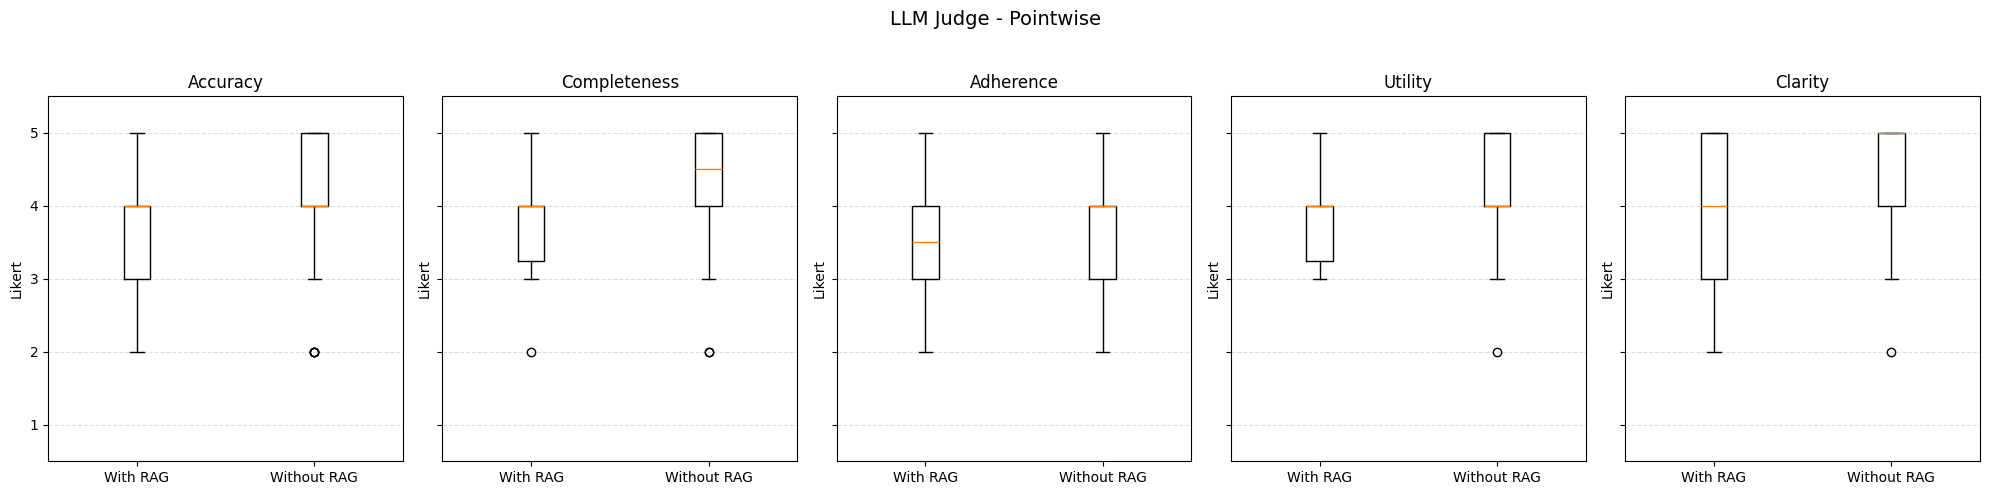

In [81]:
plot_boxplots_todas_dimensoes(
    df=df_analise,
    dict_dimensoes=dict_dim_pointwise,
    titulo_geral="LLM Judge - Pointwise",
    label_rag="With RAG",
    label_gpt="Without RAG"
)

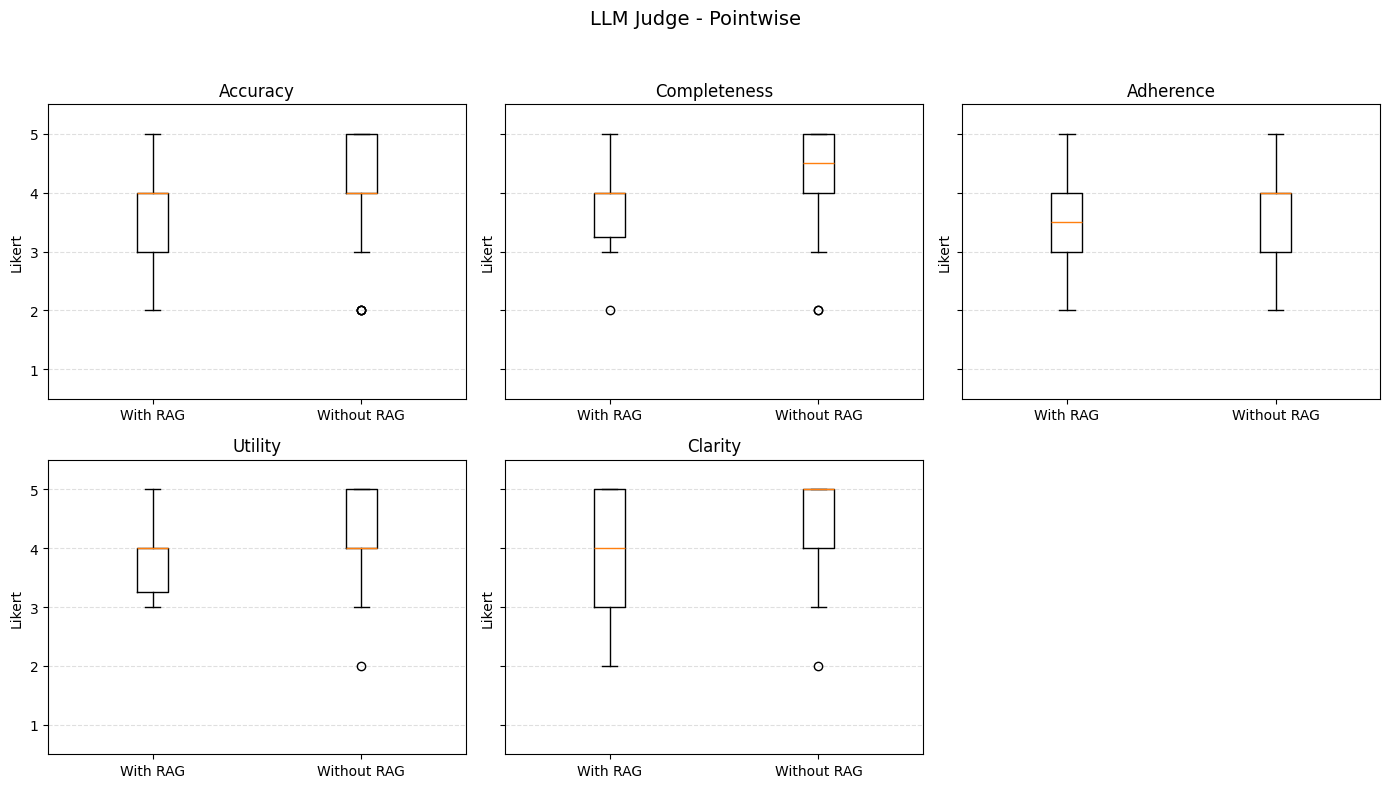

In [82]:
plot_boxplots_todas_dimensoes_grid(
    df=df_analise,
    dict_dimensoes=dict_dim_pointwise,
    titulo_geral="LLM Judge - Pointwise",    
    label_rag="With RAG",
    label_gpt="Without RAG"
)

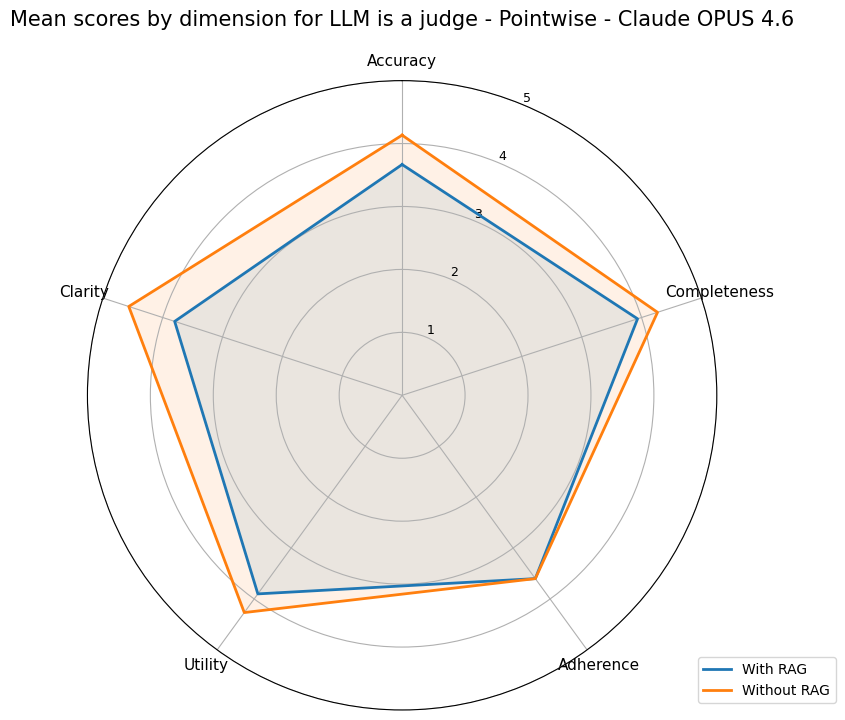

In [105]:
plot_radar_medias_dimensoes(
    df_estatisticas=df_estat_pointwise,
    titulo="Mean scores by dimension for LLM is a judge - Pointwise - Claude OPUS 4.6",
    figsize=(8, 8),
    title_fontsize=15,
    axis_label_fontsize=11,
    radial_tick_fontsize=9,
    legend_fontsize=10,
    label_rag="With RAG",
    label_gpt="Without RAG"
)

### Linha 2: pairwise

In [84]:
dict_dim_pairwise

{'Accuracy': ('Accuracy_rag_enabled_llm_judge_pairwise',
  'Accuracy_rag_disabled_llm_judge_pairwise'),
 'Completeness': ('Completeness_rag_enabled_llm_judge_pairwise',
  'Completeness_rag_disabled_llm_judge_pairwise'),
 'Adherence': ('Adherence_rag_enabled_llm_judge_pairwise',
  'Adherence_rag_disabled_llm_judge_pairwise'),
 'Utility': ('Utility_rag_enabled_llm_judge_pairwise',
  'Utility_rag_disabled_llm_judge_pairwise'),
 'Clarity': ('Clarity_rag_enabled_llm_judge_pairwise',
  'Clarity_rag_disabled_llm_judge_pairwise')}

In [85]:
df_estat_pairwise = calcular_estatisticas_todas_dimensoes(df = df_analise,
                                                            dict_dimensoes = dict_dim_pairwise)

In [86]:
df_estat_pairwise

,dimension,column_rag_enabled,column_gpt_disabled,mean_rag_enabled,mean_rag_disabled,median_rag_enabled,median_rag_disabled,std_rag_enabled,std_rag_disabled,n_rag_enabled,n_rag_disabled
0,Accuracy,Accuracy_rag_enabled_llm_judge_pairwise,Accuracy_rag_disabled_llm_judge_pairwise,4.133333,4.000000,4.0,4.0,0.628810,1.174440,30,30
1,Completeness,Completeness_rag_enabled_llm_judge_pairwise,Completeness_rag_disabled_llm_judge_pairwise,4.366667,4.200000,4.5,5.0,0.764890,1.063501,30,30
2,Adherence,Adherence_rag_enabled_llm_judge_pairwise,Adherence_rag_disabled_llm_judge_pairwise,3.933333,3.700000,4.0,4.0,0.739680,0.952311,30,30
3,Utility,Utility_rag_enabled_llm_judge_pairwise,Utility_rag_disabled_llm_judge_pairwise,4.266667,4.300000,4.0,5.0,0.691492,1.055364,30,30
4,Clarity,Clarity_rag_enabled_llm_judge_pairwise,Clarity_rag_disabled_llm_judge_pairwise,3.500000,4.433333,4.0,5.0,0.973795,0.897634,30,30


In [87]:
df_estat_wilcox_pairwise = calcular_estatisticas_todas_dimensoes_com_wilcoxon(
    df=df_analise,
    dict_dimensoes=dict_dim_pairwise,
    alternative="two-sided"
)

/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning

In [88]:
df_estat_wilcox_pairwise

,dimension,column_rag_enabled,column_gpt_disabled,mean_rag_enabled,mean_gpt_disabled,median_rag_enabled,median_gpt_disabled,std_rag_enabled,std_gpt_disabled,n_pares,median_diff_rag_minus_gpt,wilcoxon_stat,wilcoxon_pvalue
0,Accuracy,Accuracy_rag_enabled_llm_judge_pairwise,Accuracy_rag_disabled_llm_judge_pairwise,4.133333,4.000000,4.0,4.0,0.628810,1.174440,30,0.0,97.0,0.753132
1,Completeness,Completeness_rag_enabled_llm_judge_pairwise,Completeness_rag_disabled_llm_judge_pairwise,4.366667,4.200000,4.5,5.0,0.764890,1.063501,30,0.0,86.0,0.465826
2,Adherence,Adherence_rag_enabled_llm_judge_pairwise,Adherence_rag_disabled_llm_judge_pairwise,3.933333,3.700000,4.0,4.0,0.739680,0.952311,30,0.0,131.5,0.378169
3,Utility,Utility_rag_enabled_llm_judge_pairwise,Utility_rag_disabled_llm_judge_pairwise,4.266667,4.300000,4.0,5.0,0.691492,1.055364,30,0.0,141.0,0.788021
4,Clarity,Clarity_rag_enabled_llm_judge_pairwise,Clarity_rag_disabled_llm_judge_pairwise,3.500000,4.433333,4.0,5.0,0.973795,0.897634,30,-1.0,82.0,0.004872


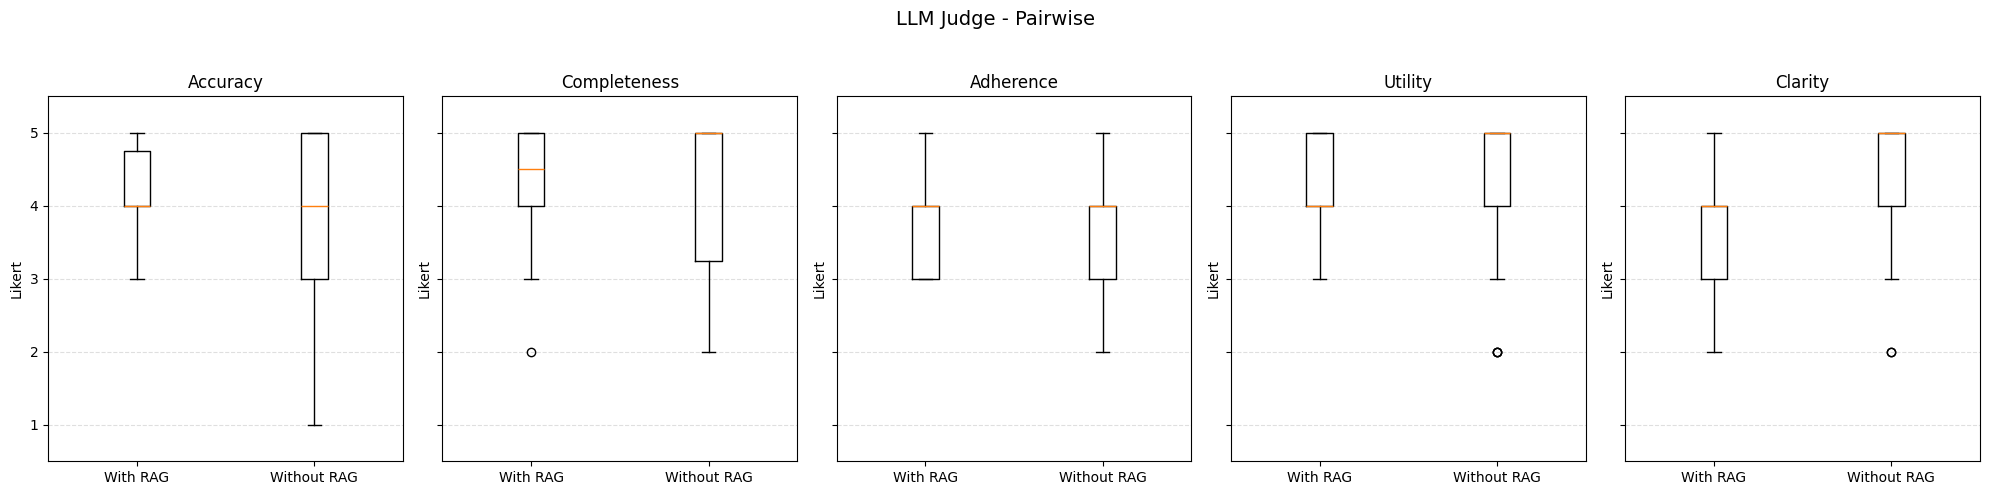

In [89]:
plot_boxplots_todas_dimensoes(
    df=df_analise,
    dict_dimensoes=dict_dim_pairwise,
    titulo_geral="LLM Judge - Pairwise",    
    label_rag="With RAG",
    label_gpt="Without RAG"
)

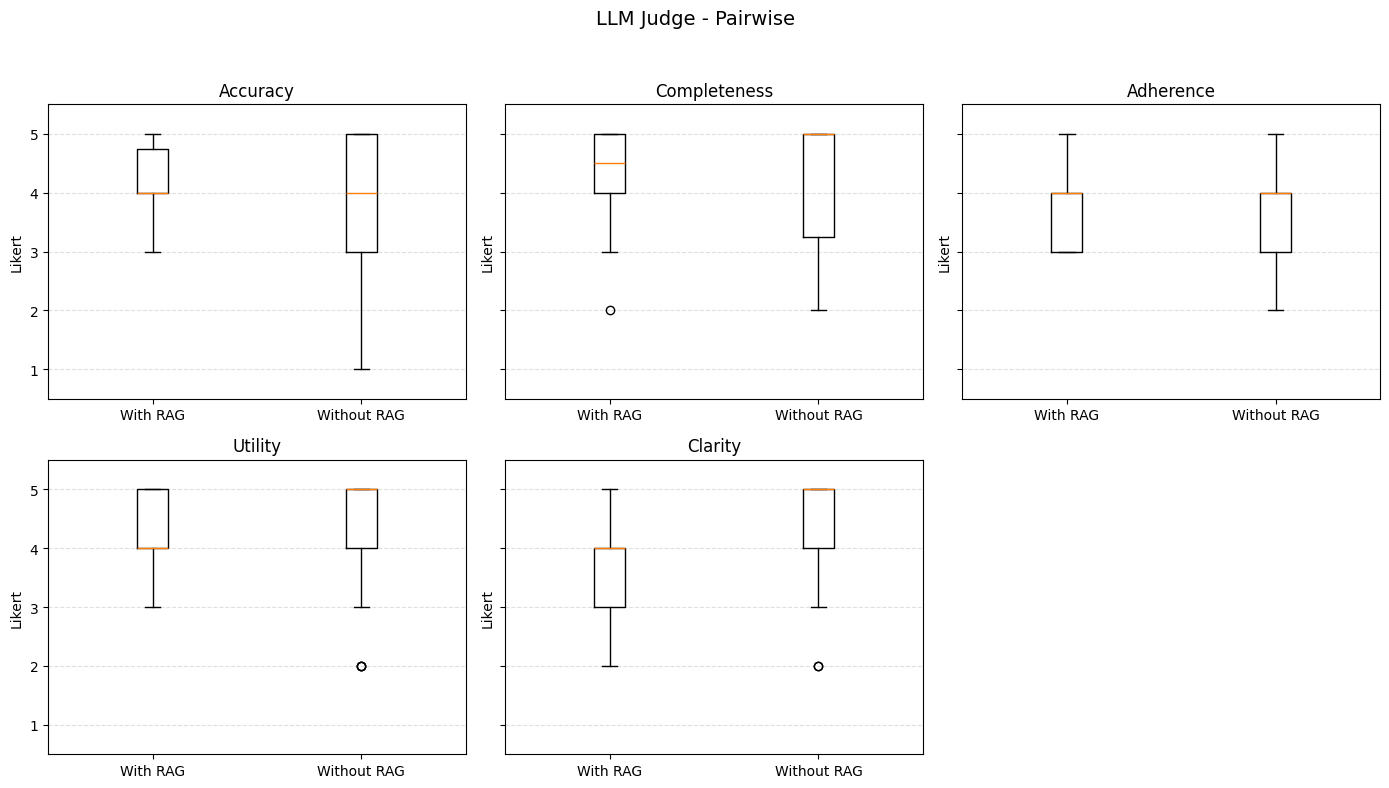

In [90]:
plot_boxplots_todas_dimensoes_grid(
    df=df_analise,
    dict_dimensoes=dict_dim_pairwise,
    titulo_geral="LLM Judge - Pairwise",    
    label_rag="With RAG",
    label_gpt="Without RAG"
)

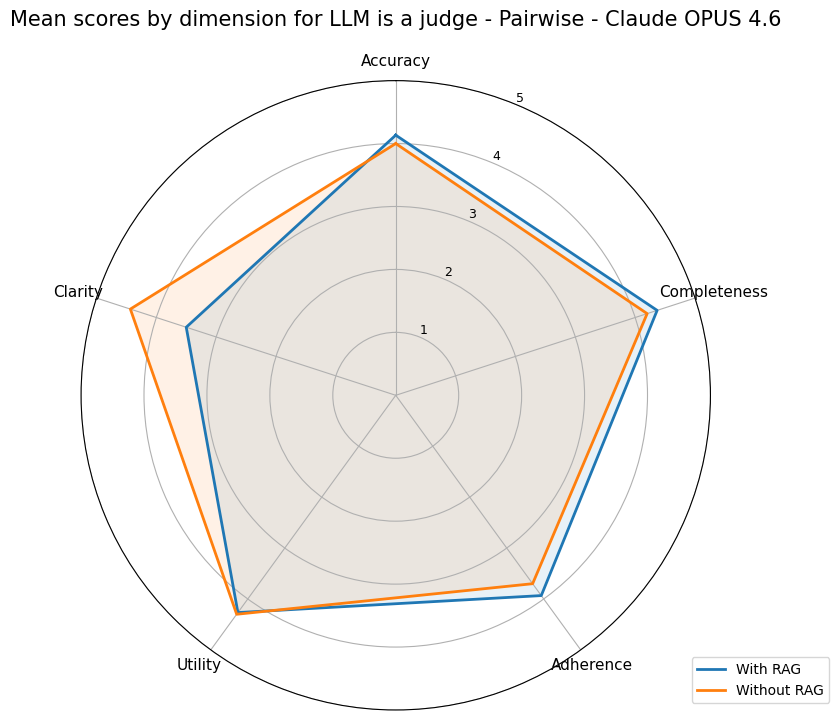

In [104]:
plot_radar_medias_dimensoes(
    df_estatisticas=df_estat_pairwise,
    titulo="Mean scores by dimension for LLM is a judge - Pairwise - Claude OPUS 4.6",
    figsize=(8, 8),
    title_fontsize=15,
    axis_label_fontsize=11,
    radial_tick_fontsize=9,
    legend_fontsize=10,    
    label_rag="With RAG",
    label_gpt="Without RAG"
)

### Comparativo preferência global

In [106]:
df_analise.head(2)

,ID,question,response_A,response_B,A_origin,Accuracy_rag_enabled_llm_judge_pointwise,Completeness_rag_enabled_llm_judge_pointwise,Adherence_rag_enabled_llm_judge_pointwise,Utility_rag_enabled_llm_judge_pointwise,Clarity_rag_enabled_llm_judge_pointwise,Accuracy_rag_disabled_llm_judge_pointwise,Completeness_rag_disabled_llm_judge_pointwise,Adherence_rag_disabled_llm_judge_pointwise,Utility_rag_disabled_llm_judge_pointwise,Clarity_rag_disabled_llm_judge_pointwise,Accuracy_rag_enabled_llm_judge_pairwise,Completeness_rag_enabled_llm_judge_pairwise,Adherence_rag_enabled_llm_judge_pairwise,Utility_rag_enabled_llm_judge_pairwise,Clarity_rag_enabled_llm_judge_pairwise,Accuracy_rag_disabled_llm_judge_pairwise,Completeness_rag_disabled_llm_judge_pairwise,Adherence_rag_disabled_llm_judge_pairwise,Utility_rag_disabled_llm_judge_pairwise,Clarity_rag_disabled_llm_judge_pairwise,global_preference_llm_judge_origin
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",rag_disabled,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,3,3,4,rag_enabled
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatórios.\n•Responsabilização e prestação de contas: demonstração da adoção de medidas eficazes para cumprir as normas de proteção de dados pessoais","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis.",

In [107]:
df_analise["global_preference_llm_judge_origin"].unique()

array(['rag_enabled', 'rag_disabled', 'tie'], dtype=object)

In [108]:

def analisar_preferencia_global(
    df: pd.DataFrame,
    coluna_preferencia: str = "preferencia_global_llm_judge_origem"
) -> pd.DataFrame:
    """
    Faz uma análise simples da preferência global.
    
    Espera valores como:
    - rag_enabled
    - rag_disabled
    - tie
    """

    if coluna_preferencia not in df.columns:
        raise ValueError(f"A coluna '{coluna_preferencia}' não está no dataframe.")

    serie = (
        df[coluna_preferencia]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    categorias_esperadas = ["rag_enabled", "rag_disabled", "tie"]

    contagens = serie.value_counts(dropna=False)
    total = len(serie)

    resultados = []
    for cat in categorias_esperadas:
        n = int(contagens.get(cat, 0))
        perc = (n / total * 100) if total > 0 else 0.0
        resultados.append({
            "category": cat,
            "n": n,
            "percentage": perc
        })

    df_resultado = pd.DataFrame(resultados)

    # métricas extras
    n_rag = int(contagens.get("rag_enabled", 0))
    n_gpt = int(contagens.get("rag_disabled", 0))
    n_empate = int(contagens.get("tie", 0))
    n_decididos = n_rag + n_gpt

    taxa_vitoria_rag = (n_rag / n_decididos * 100) if n_decididos > 0 else None
    taxa_vitoria_gpt = (n_gpt / n_decididos * 100) if n_decididos > 0 else None

    resumo = pd.DataFrame([
        {
            "total_observations": total,
            "n_decided_without_empate": n_decididos,
            "n_tie": n_empate,
            "win_rate_rag_enabled_without_tie": taxa_vitoria_rag,
            "win_rate_rag_disabled_without_tie": taxa_vitoria_gpt
        }
    ])

    return df_resultado, resumo

In [ ]:
def plot_preferencia_global(
    df: pd.DataFrame,
    coluna_preferencia: str = "global_preference_llm_judge_origin",
    titulo: str = "Global Preference of the LLM is a Judge",
    fontsize_titulo: int = 12,
    fontsize_eixos: int = 10,
    fontsize_valores: int = 10
):
    serie = (
        df[coluna_preferencia]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    categorias = ["rag_enabled", "rag_disabled", "tie"]
    contagens = [int((serie == cat).sum()) for cat in categorias]

    fig, ax = plt.subplots(figsize=(6, 4))
    barras = ax.bar(categorias, contagens)

    ax.set_title(titulo, fontsize=fontsize_titulo)
    ax.set_ylabel("Frequency", fontsize=fontsize_eixos)
    ax.set_xlabel("Category", fontsize=fontsize_eixos)
    ax.set_ylim(0, 25)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # adiciona os valores acima das barras
    for barra, valor in zip(barras, contagens):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.1,
            str(valor),
            ha="center",
            va="bottom",
            fontsize=fontsize_valores
        )

    plt.tight_layout()
    plt.show()

In [109]:
def plot_preferencia_global(
    df: pd.DataFrame,
    coluna_preferencia: str = "global_preference_llm_judge_origin",
    titulo: str = "Global Preference of the LLM is a Judge",
    categorias: list = ["rag_enabled", "rag_disabled", "tie"],
    fontsize_titulo: int = 12,
    fontsize_eixos: int = 10,
    fontsize_valores: int = 10
):
    serie = (
        df[coluna_preferencia]
        .astype(str)
        .str.strip()
    )
    
    contagens = [int((serie == cat).sum()) for cat in categorias]

    fig, ax = plt.subplots(figsize=(6, 4))
    barras = ax.bar(categorias, contagens)

    ax.set_title(titulo, fontsize=fontsize_titulo)
    ax.set_ylabel("Frequency", fontsize=fontsize_eixos)
    ax.set_xlabel("Category", fontsize=fontsize_eixos)
    ax.set_ylim(0, 25)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # adiciona os valores acima das barras
    for barra, valor in zip(barras, contagens):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.1,
            str(valor),
            ha="center",
            va="bottom",
            fontsize=fontsize_valores
        )

    plt.tight_layout()
    plt.show()

In [110]:
df_pref_global, df_pref_global_resumo = analisar_preferencia_global(
    df=df_analise,
    coluna_preferencia="global_preference_llm_judge_origin"
)


In [111]:
df_pref_global

,category,n,percentage
0,rag_enabled,10,33.333333
1,rag_disabled,15,50.000000
2,tie,5,16.666667


In [112]:
df_pref_global_resumo

,total_observations,n_decided_without_empate,n_tie,win_rate_rag_enabled_without_tie,win_rate_rag_disabled_without_tie
0,30,25,5,40.0,60.0


In [113]:
# aplica uma mudanca na coluna
df_analise.head(2)

,ID,question,response_A,response_B,A_origin,Accuracy_rag_enabled_llm_judge_pointwise,Completeness_rag_enabled_llm_judge_pointwise,Adherence_rag_enabled_llm_judge_pointwise,Utility_rag_enabled_llm_judge_pointwise,Clarity_rag_enabled_llm_judge_pointwise,Accuracy_rag_disabled_llm_judge_pointwise,Completeness_rag_disabled_llm_judge_pointwise,Adherence_rag_disabled_llm_judge_pointwise,Utility_rag_disabled_llm_judge_pointwise,Clarity_rag_disabled_llm_judge_pointwise,Accuracy_rag_enabled_llm_judge_pairwise,Completeness_rag_enabled_llm_judge_pairwise,Adherence_rag_enabled_llm_judge_pairwise,Utility_rag_enabled_llm_judge_pairwise,Clarity_rag_enabled_llm_judge_pairwise,Accuracy_rag_disabled_llm_judge_pairwise,Completeness_rag_disabled_llm_judge_pairwise,Adherence_rag_disabled_llm_judge_pairwise,Utility_rag_disabled_llm_judge_pairwise,Clarity_rag_disabled_llm_judge_pairwise,global_preference_llm_judge_origin
0,1,Quais são os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados? (Limite a resposta em 100 palavras),"O Decreto 10.046/2019 define que a Secretaria de Governo Digital atua como autoridade central de dados, com responsabilidade por diretrizes, interoperabilidade, segurança e compartilhamento. Cada órgão do Executivo mantém unidades responsáveis por governança, catalogação, classificação e qualidade dos próprios dados, além de pontos focais para integração ao governo digital. Comitês internos e interinstitucionais coordenam políticas, resolvem conflitos e monitoram conformidade. Alguns detalhes podem ter mudado recentemente.","Os principais papéis e responsabilidades definidos pelo Poder Executivo Federal para a governança de dados incluem:\n\nExecutivo de Dados: responsável por coordenar a implementação do Programa de Governança de Dados, desenvolver processos, gerir a catalogação de dados, entre outras funções.\nInstância Estratégica de Governança de Dados: supervisiona e faz cumprir as diretrizes da política de Governança de Dados, decide sobre mudanças na política, aprova políticas de gestão de dados, entre outras responsabilidades",rag_disabled,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,3,3,4,rag_enabled
1,2,"Segundo a LGPD, quais são os princípios fundamentais para o tratamento de dados pessoais?(Limite a resposta em 100 palavras)","Os princípios fundamentais para o tratamento de dados pessoais segundo a LGPD são:\n\n•Finalidade: o tratamento deve ser realizado para propósitos legítimos, específicos, explícitos e informados ao titular.\n•Adequação: o tratamento deve ser compatível com as finalidades informadas ao titular, de acordo com o contexto do tratamento.\n•Necessidade: o tratamento deve ser limitado ao mínimo necessário para suas finalidades, com dados pertinentes, proporcionais e não excessivos.\n•Livre acesso: garantia de consulta facilitada e gratuita sobre o tratamento e os dados pessoais.\n•Qualidade dos dados: garantia de exatidão, clareza, relevância e atualização dos dados.\n•Transparência: fornecimento de informações claras e acessíveis sobre o tratamento e os agentes envolvidos.\n•Segurança: utilização de medidas para proteger os dados contra acessos não autorizados e situações acidentais.\n•Prevenção: adoção de medidas para prevenir danos decorrentes do tratamento.\n•Não discriminação: proibição do tratamento para fins discriminatórios.\n•Responsabilização e prestação de contas: demonstração da adoção de medidas eficazes para cumprir as normas de proteção de dados pessoais","A LGPD estabelece que o tratamento de dados pessoais deve seguir princípios como finalidade específica e legítima, adequação ao contexto do uso, necessidade com mínima coleta possível, garantia de livre acesso e qualidade das informações, transparência sobre as operações, segurança e prevenção contra danos, além da vedação a discriminações. Também exige responsabilização e prestação de contas por parte do agente de tratamento, assegurando que todas as práticas sejam justificadas e auditáveis.",

In [114]:
df_grafico = df_analise.copy()

# na coluna "global_preference_llm_judge_origin", vamos trocar "rag_enabled" por "With RAG", "rag_disabled" por "Without RAG" e "tie" por "Tie"
df_grafico["global_preference_llm_judge_origin"] = df_grafico["global_preference_llm_judge_origin"].replace({
    "rag_enabled": "With RAG",
    "rag_disabled": "Without RAG",
    "tie": "Tie"
})
df_grafico["global_preference_llm_judge_origin"].value_counts()

global_preference_llm_judge_origin
Without RAG    15
With RAG       10
Tie             5
Name: count, dtype: int64

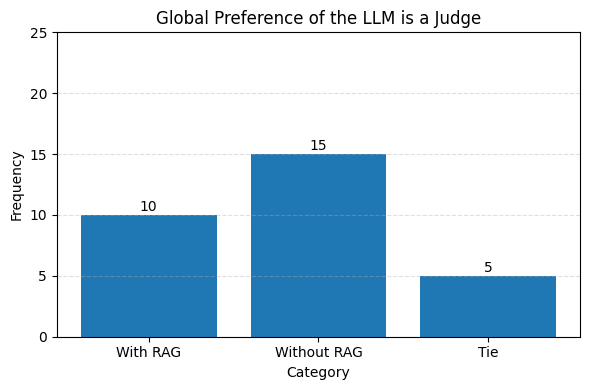

In [117]:
plot_preferencia_global(df = df_grafico,
                        coluna_preferencia="global_preference_llm_judge_origin",
                        titulo="Global Preference of the LLM is a Judge",
                        categorias=["With RAG", "Without RAG", "Tie"])